# Accident Classification 

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
import cv2
import os
import random

In [ ]:
tf.keras.utils.set_random_seed(42)

# **Read Data**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ckay16/accident-detection-from-cctv-footage")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'accident-detection-from-cctv-footage' dataset.
Path to dataset files: /kaggle/input/accident-detection-from-cctv-footage


# **Directories**

In [ ]:
BASE_DIR = os.path.join(path, 'data')

train_dir = os.path.join(BASE_DIR, 'train')
val_dir = os.path.join(BASE_DIR, 'val')
test_dir=os.path.join(BASE_DIR, 'test')

In [ ]:
classes = ["Non Accident", "Accident"]
for c in classes:
    train_path = os.path.join(train_dir, c)
    val_path = os.path.join(val_dir, c)
    test_path = os.path.join(test_dir, c)

# **Functions**

In [ ]:
IMAGE_SIZE = (224,224)
BATCH_SIZE = 16

def load_images_and_labels(directory, label):
    images = []
    labels = []
    # List only files that are likely images to avoid errors with directories or hidden files
    image_files = [f for f in os.listdir(directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    for filename in image_files:
        filepath = os.path.join(directory, filename)
        image = cv2.imread(filepath) # Use OpenCV to read imag
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)# convert from BGR to RGB
        image = cv2.resize(image, IMAGE_SIZE) # Resize image
        images.append(image)
        labels.append(label)
    return images, labels

# **Load Accident**

In [ ]:
train_accident, y_train_accident = load_images_and_labels(
    os.path.join(train_dir, "Accident"),
    1
) # train_accident: train accident images , y_train_accident: train accident labels(1)

val_accident, y_val_accident = load_images_and_labels(
    os.path.join(val_dir, "Accident"),
    1
)

test_accident, y_test_accident = load_images_and_labels(
    os.path.join(test_dir, "Accident"),
    1
)

print("Train Accident:", len(train_accident))
print("Validation Accident:", len(val_accident))
print("Test Accident:", len(test_accident))

Train Accident: 369
Validation Accident: 46
Test Accident: 47


# **Load Non Accident**

In [ ]:
train_non_accident, y_train_non_accident = load_images_and_labels(
    os.path.join(train_dir, "Non Accident"),
    0
) # train_accident: train non_accident images , y_train_accident: train non_accident labels(0)

val_non_accident, y_val_non_accident = load_images_and_labels(
    os.path.join(val_dir, "Non Accident"),
    0
)

test_non_accident, y_test_non_accident = load_images_and_labels(
    os.path.join(test_dir, "Non Accident"),
    0
)

print("Train Non Accident:", len(train_non_accident))
print("Validation Non Accident:", len(val_non_accident))
print("Test Non Accident:", len(test_non_accident))

Train Non Accident: 422
Validation Non Accident: 52
Test Non Accident: 53


# **Combine training data**

In [ ]:
x_train = np.array(train_accident + train_non_accident) # contain all train images
y_train = np.array(y_train_accident + y_train_non_accident) # contain all train labels

print("x_train shape:",x_train.shape)
print("y_train shape:",y_train.shape)

x_train shape: (791, 224, 224, 3)
y_train shape: (791,)


# **Visualize training samples**

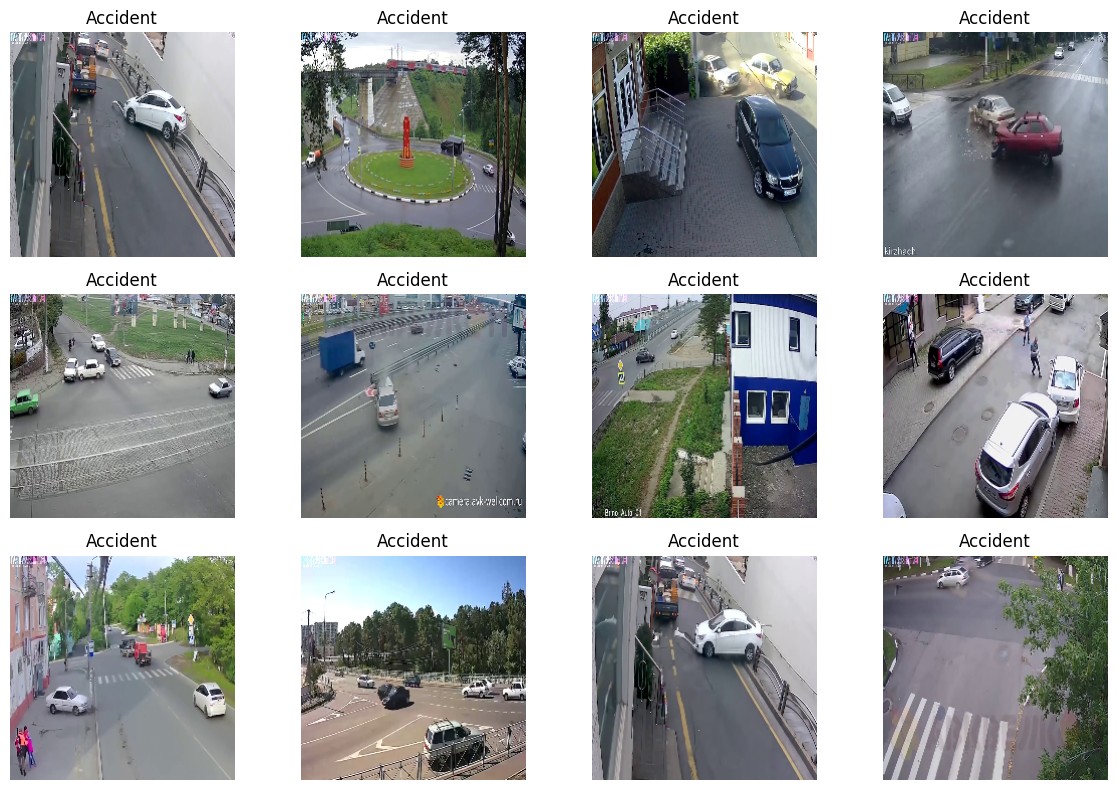

In [ ]:
plt.figure(figsize=(12, 8))
for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i].astype("uint8"))
    plt.title(classes[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# **Combine validation data**

In [ ]:
x_val = np.array(val_accident + val_non_accident)
y_val = np.array(y_val_accident + y_val_non_accident)

print("x_val shape:",x_val.shape)
print("y_val shape:",y_val.shape)

x_val shape: (98, 224, 224, 3)
y_val shape: (98,)


# **Combine test data**

In [ ]:
x_test = np.array(test_accident + test_non_accident)
y_test = np.array(y_test_accident + y_test_non_accident)

print("x_test shape:",x_test.shape)
print("y_test shape:",y_test.shape)

x_test shape: (100, 224, 224, 3)
y_test shape: (100,)


# **Shuffle the data**

In [ ]:
def shuffle_data(images, labels):
    combined = list(zip(images, labels))
    random.shuffle(combined)

    shuffled_images, shuffled_labels = zip(*combined)

    return np.array(shuffled_images), np.array(shuffled_labels)

In [ ]:
x_train, y_train = shuffle_data(x_train, y_train)
x_val, y_val = shuffle_data(x_val, y_val)
x_test, y_test = shuffle_data(x_test, y_test)

# **Image Preprocessing**

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

# EfficientNetB0 in tf.keras includes its own input rescaling internally,
# so efficientnet.preprocess_input is effectively a pass-through (unlike
# MobileNetV2's preprocess_input, which rescales to [-1, 1]). Keeping the
# call here — instead of skipping it — means predict_image() and this
# preprocessing step stay in sync automatically.
x_train = preprocess_input(x_train)
x_test = preprocess_input(x_test)
x_val = preprocess_input(x_val)


# **Class weights**
The classes are only mildly imbalanced (369 vs 422 in train), but weighting costs nothing and removes it as a variable.

In [ ]:
from collections import Counter

counts = Counter(y_train.tolist())
total = sum(counts.values())
num_classes = len(counts)
class_weight = {cls: total / (num_classes * count) for cls, count in counts.items()}
print("Class weights:", class_weight)


Class weights: {0: 0.9372037914691943, 1: 1.0718157181571815}


# **Augmentation**
Added translation and contrast jitter on top of flip/rotation/zoom.

In [ ]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomTranslation(0.05, 0.05),
    keras.layers.RandomContrast(0.1),
])


# **Model Creation**

In [ ]:
base_model = keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,  # cut output layer
    weights="imagenet"
)
base_model.trainable = False


In [ ]:
model = keras.Sequential([
    keras.layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    base_model,

    keras.layers.GlobalAveragePooling2D(),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.35),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.25),

    keras.layers.Dense(2, activation="softmax")
])


# **Model Summary**

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,218,917 (16.09 MB)

 Trainable params: 166,786 (651.51 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

# **Stage 1 — train the backbone frozen**

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
callbacks_stage1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, start_from_epoch=3
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
    ),
]

history1 = model.fit(
    x_train, y_train,
    epochs=25, batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    class_weight=class_weight,
    callbacks=callbacks_stage1,
)


Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - accuracy: 0.5879 - loss: 1.0162 - val_accuracy: 0.6224 - val_loss: 0.6241 - learning_rate: 3.0000e-04
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.6397 - loss: 0.8172 - val_accuracy: 0.7143 - val_loss: 0.5762 - learning_rate: 3.0000e-04
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.6915 - loss: 0.7425 - val_accuracy: 0.7143 - val_loss: 0.5499 - learning_rate: 3.0000e-04
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.6928 - loss: 0.6672 - val_accuracy: 0.7143 - val_loss: 0.5386 - learning_rate: 3.0000e-04
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.7244 - loss: 0.6269 - val_accuracy: 0.7551 - val_loss: 0.5174 - learning_rate: 3.0000e-04
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.7358 - loss: 0.5910 - val_accuracy: 0.7857 - val_loss: 0.4785 - learning_rate: 3.0000e-04
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.750

# **Stage 2 — fine-tune the top of EfficientNetB0**

In [ ]:
base_model.trainable = True
fine_tune_from = int(len(base_model.layers) * 0.70)

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_from:]:
    layer.trainable = not isinstance(layer, keras.layers.BatchNormalization)

trainable_count = sum(l.trainable for l in base_model.layers)
print(f"Trainable EfficientNetB0 layers: {trainable_count}/{len(base_model.layers)}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_stage2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=6, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        "best_crash_detection_efficientnetb0.keras",
        monitor="val_accuracy", save_best_only=True
    ),
]

history2 = model.fit(
    x_train, y_train,
    epochs=20, batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    class_weight=class_weight,
    callbacks=callbacks_stage2,
)


Trainable EfficientNetB0 layers: 57/238
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.7851 - loss: 0.4646 - val_accuracy: 0.7959 - val_loss: 0.3868 - learning_rate: 1.0000e-05
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.8104 - loss: 0.4093 - val_accuracy: 0.8265 - val_loss: 0.3769 - learning_rate: 1.0000e-05
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.8116 - loss: 0.4195 - val_accuracy: 0.8061 - val_loss: 0.3706 - learning_rate: 1.0000e-05
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.8091 - loss: 0.4363 - val_accuracy: 0.8163 - val_loss: 0.3660 - learning_rate: 1.0000e-05
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.7939 - loss: 0.4465 - val_accuracy: 0.8061 - val_loss: 0.3619 - learning_rate: 1.0000e-05
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.8142 - loss: 0.3907 - val_accuracy: 0.8163 - val_loss: 0.3545 - learning_rate: 1.0000e-05
Epoch 7/20
50/50 ━━━━━━━━━━━

# **Visualization**

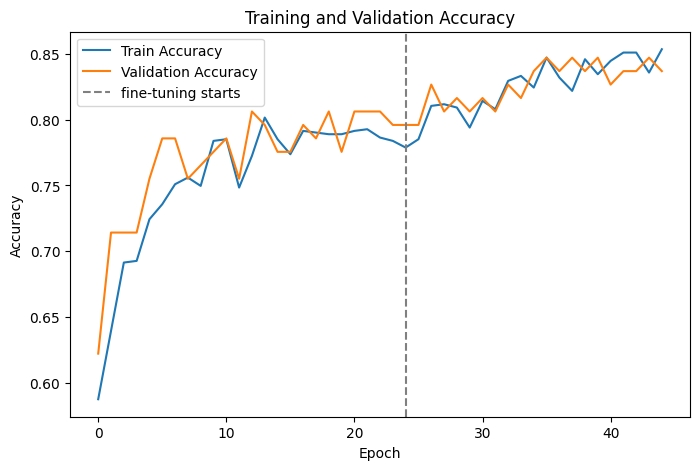

In [ ]:
def combine_history(h1, h2):
    return {k: h1.history.get(k, []) + h2.history.get(k, []) for k in set(h1.history) | set(h2.history)}

history = combine_history(history1, history2)
split_epoch = len(history1.history["accuracy"]) - 1

plt.figure(figsize=(8, 5))
plt.plot(history["accuracy"], label="Train Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.axvline(split_epoch, linestyle="--", color="gray", label="fine-tuning starts")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


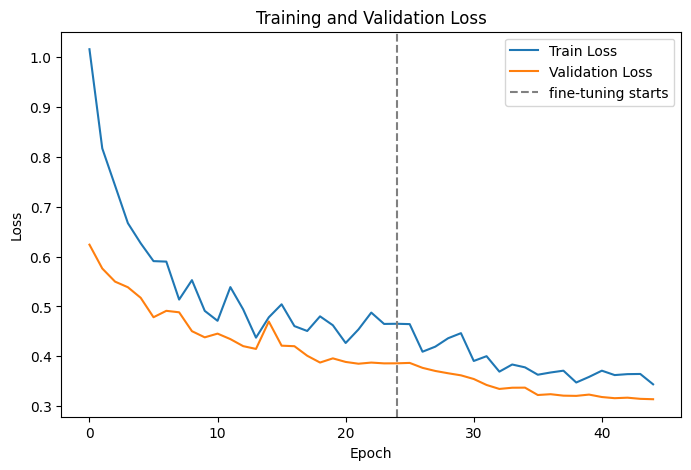

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history["loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.axvline(split_epoch, linestyle="--", color="gray", label="fine-tuning starts")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


# **Evaluation**

In [ ]:
y_train_prob = model.predict(x_train, verbose=0)
y_train_pred = np.argmax(y_train_prob, axis=1)

y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)


In [ ]:
print("train classification_report:")
print(classification_report(y_train, y_train_pred, target_names=classes))
print("test classification_report:")
print(classification_report(y_test, y_pred, target_names=classes))


train classification_report:
              precision    recall  f1-score   support

Non Accident       0.88      0.91      0.90       422
    Accident       0.90      0.85      0.88       369

    accuracy                           0.89       791
   macro avg       0.89      0.88      0.89       791
weighted avg       0.89      0.89      0.89       791

test classification_report:
              precision    recall  f1-score   support

Non Accident       0.91      0.98      0.95        53
    Accident       0.98      0.89      0.93        47

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



Test ROC-AUC: 0.9442


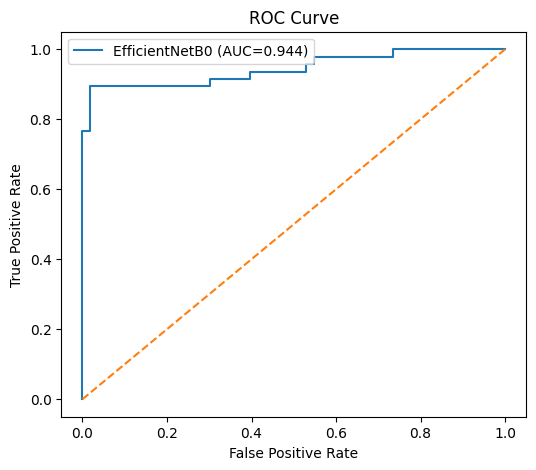

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

# y_prob[:, 1] = probability of the "Accident" class (index 1)
auc = roc_auc_score(y_test, y_prob[:, 1])
print(f"Test ROC-AUC: {auc:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"EfficientNetB0 (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


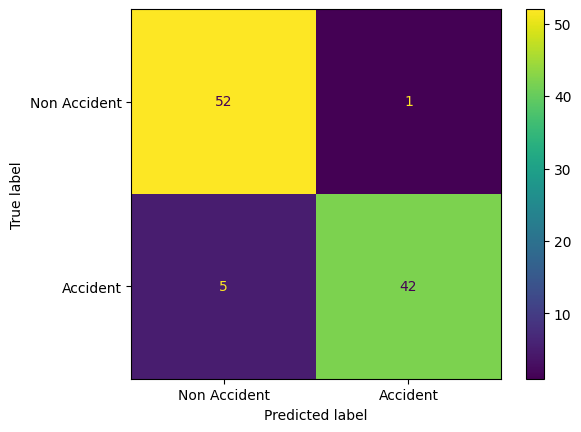

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.show()


# **Inference**

In [ ]:
CLASS_NAMES = ["Non Accident", "Accident"]

def predict_image(filepath):
    image = tf.keras.utils.load_img(filepath, target_size=IMAGE_SIZE)
    image_array = tf.keras.utils.img_to_array(image)
    image_array = preprocess_input(image_array)
    image_array = np.expand_dims(image_array, axis=0)

    probs = model.predict(image_array, verbose=0)[0]
    predicted_label = int(np.argmax(probs))
    predicted_class = CLASS_NAMES[predicted_label]
    confidence = float(probs[predicted_label])

    print("Prediction:", predicted_class)
    print(f"Confidence: {confidence:.2%}")

    return predicted_class, confidence


In [ ]:
test_image = os.path.join(test_dir, "Accident", "test18_22.jpg")
predict_image(test_image)


Prediction: Non Accident
Confidence: 94.29%


('Non Accident', 0.942859411239624)

In [ ]:
test_image = os.path.join(test_dir, "Non Accident", "test4_53.jpg")
predict_image(test_image)


Prediction: Non Accident
Confidence: 64.49%


('Non Accident', 0.6448813080787659)

In [ ]:
import glob
accident_images = glob.glob(os.path.join(test_dir, "Accident", "*"))
non_accident_images = glob.glob(os.path.join(test_dir, "Non Accident", "*"))

print("Number of accident images:", len(accident_images))
print("Number of non-accident images:", len(non_accident_images))
if accident_images:
    print("First image:", accident_images[0])

Number of accident images: 47
Number of non-accident images: 54
First image: /kaggle/input/accident-detection-from-cctv-footage/data/test/Accident/test18_22.jpg


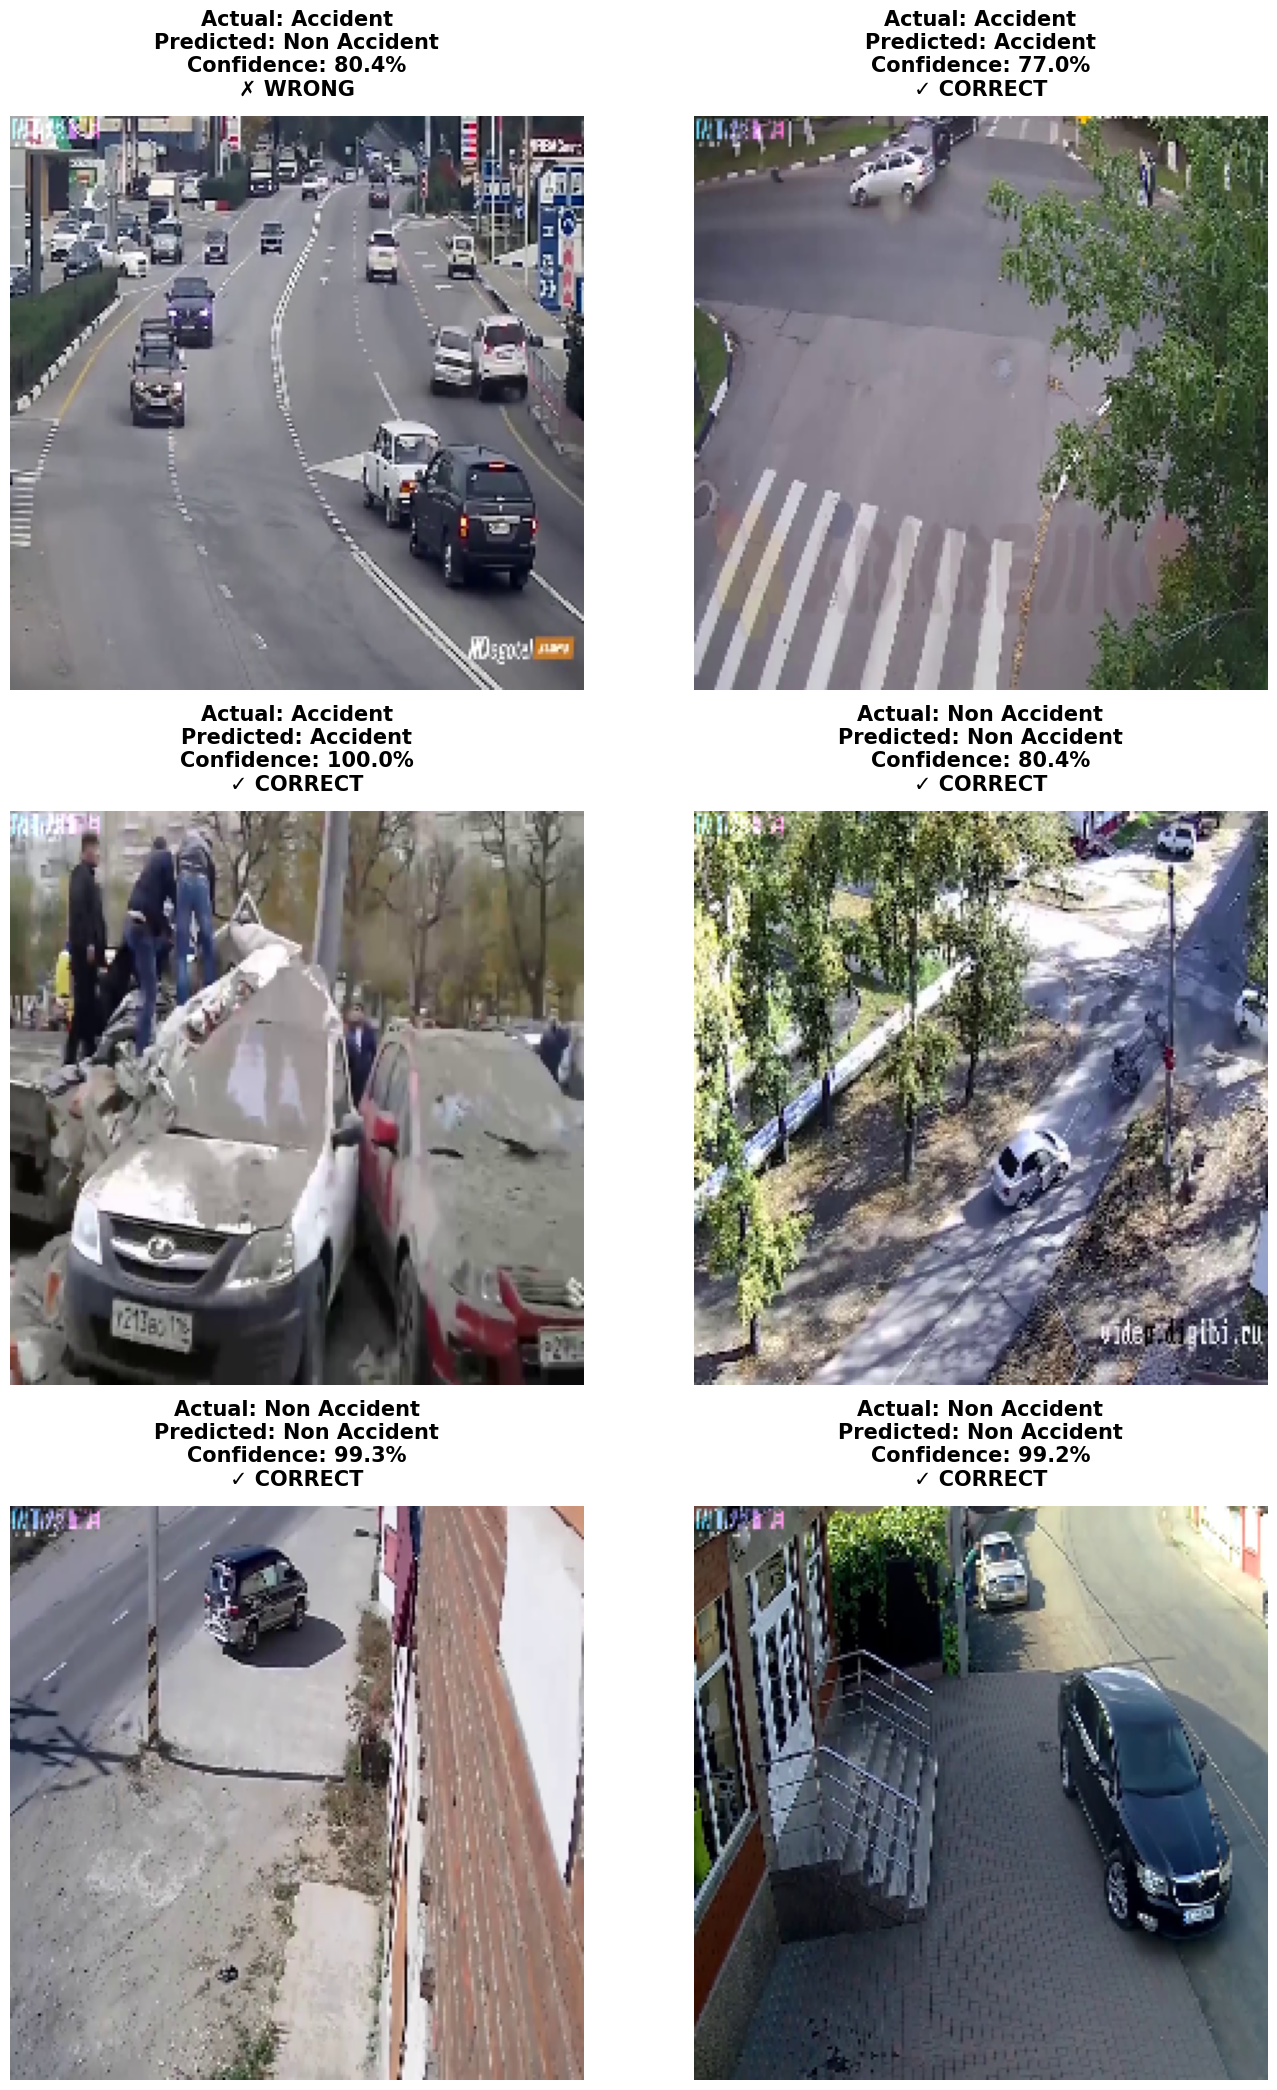

In [ ]:
import os
import glob
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import math



num_images = 6

# Make sure we don't request more than available
num_images = min(
    num_images,
    len(accident_images) + len(non_accident_images)
)

# Select approximately half from each class
n_accident = num_images // 2
n_non_accident = num_images - n_accident

selected_accidents = random.sample(
    accident_images,
    min(n_accident, len(accident_images))
)

selected_non_accidents = random.sample(
    non_accident_images,
    min(n_non_accident, len(non_accident_images))
)

selected_images = selected_accidents + selected_non_accidents

# Shuffle
random.shuffle(selected_images)

# ---------------------------------------------------------
# 3. Create the EXACT number of axes needed
# ---------------------------------------------------------
cols = 2
rows = math.ceil(len(selected_images) / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(14, 7 * rows)
)

# Make axes always iterable
axes = np.array(axes).reshape(-1)

# ---------------------------------------------------------
# 4. Predict and display
# ---------------------------------------------------------
for i, filepath in enumerate(selected_images):

    # Load image
    image = tf.keras.utils.load_img(
        filepath,
        target_size=IMAGE_SIZE
    )

    image_array = tf.keras.utils.img_to_array(image)

    # Predict
    probs = model.predict(
        np.expand_dims(image_array, axis=0),
        verbose=0
    )[0]

    predicted_label = int(np.argmax(probs))
    predicted_class = CLASS_NAMES[predicted_label]
    confidence = probs[predicted_label]

    # Actual class
    actual_class = os.path.basename(
        os.path.dirname(filepath)
    )

    # Check correctness
    correct = predicted_class == actual_class

    # Display
    axes[i].imshow(image)
    axes[i].axis("off")

    axes[i].set_title(
        f"Actual: {actual_class}\n"
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.1%}\n"
        f"{'✓ CORRECT' if correct else '✗ WRONG'}",
        fontsize=15,
        fontweight="bold",
        pad=15
    )

# Hide unused axes
for j in range(len(selected_images), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()